[cases] total: 2,529
[labels] distribution:
         NON_COMPLIANT :   508 ( 20.1%)
         COMPLIANT     :   408 ( 16.1%)
         OTHER         :  1310 ( 51.8%)
         UNLABELED     :   303 ( 12.0%)
[labels] reliable auto (NON+COMP): 916 (36.2%)
[dist] label x country:
country        Malaysia  Vietnam
label                           
COMPLIANT           242      166
NON_COMPLIANT       477       31
OTHER               309     1001
UNLABELED           171      132
[dist] label x ESG:
esg              E    G    S
label                       
COMPLIANT      101  123  184
NON_COMPLIANT  109  140  259
OTHER          314  449  547
UNLABELED      101   59  143
[save] gold: 916 (NON=508, COMP=408)
[save] review queue: 1,613
[save] figure fig03_label_distribution (png, pdf)


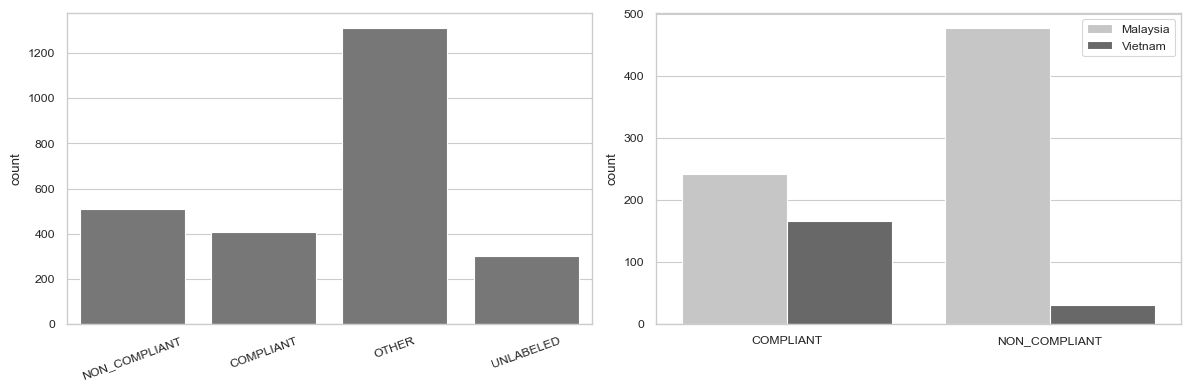


[done] notebook 03 complete.


In [1]:
# ============================================================================
# Notebook 03 · Compliance Gold-Label Derivation
# ----------------------------------------------------------------------------
# Derives compliance labels (NON_COMPLIANT / COMPLIANT / OTHER / UNLABELED)
# from legal-case case_info.result via a transparent rule, and forms a
# first-pass gold set from the reliably auto-labeled cases.
#
# Input : data/interim/source.parquet   (from notebook 01)
# Output: data/processed/compliance_gold.parquet
#         data/processed/compliance_review_queue.parquet
#         results/tables/table03_*.csv, results/figures/fig03_* (png, pdf)
#
# Scope caveat: the label is a proxy for "legal liability established", NOT for
# "disclosure compliance". Naming and interpretation are bounded accordingly.
# All outputs are English-only; figures are grayscale, no titles, dpi=600.
# ============================================================================

import os
import random
from pathlib import Path

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------------------------
# 0. Paths, seed, figure styling
# ----------------------------------------------------------------------------
PROJECT_ROOT  = Path.cwd().parent
INTERIM_DIR   = PROJECT_ROOT / "data" / "interim"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR   = PROJECT_ROOT / "results" / "figures"
TABLES_DIR    = PROJECT_ROOT / "results" / "tables"
for _d in (PROCESSED_DIR, FIGURES_DIR, TABLES_DIR):
    _d.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

matplotlib.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", 40)

sns.set_theme(style="whitegrid", context="paper")
sns.set_palette("Greys_r")
FIG_DPI = 600
GREY_DARK, GREY_MID, GREY_LIGHT = "#333333", "#777777", "#BBBBBB"

def save_fig(fig, stem):
    """Save a figure as both PNG and PDF at dpi=600 (no path printed)."""
    for ext in ("png", "pdf"):
        fig.savefig(FIGURES_DIR / f"{stem}.{ext}", dpi=FIG_DPI, bbox_inches="tight")
    print(f"[save] figure {stem} (png, pdf)")

# ----------------------------------------------------------------------------
# 1. Labeling rule
# ----------------------------------------------------------------------------
# Label constants
LABEL_NON_COMPLIANT = "NON_COMPLIANT"
LABEL_COMPLIANT     = "COMPLIANT"
LABEL_OTHER         = "OTHER"       # partial / mixed / unclear -> human review
LABEL_UNLABELED     = "UNLABELED"   # result field empty

# Sanction signal tokens (Korean, as stored in case_info.result).
# NOTE: the currency unit "동" (VND) is deliberately EXCLUDED, because it also
# appears in neutral phrasing (e.g. "bears the litigation cost"), which would
# otherwise over-capture cases as sanctioned.
SANCTION_TOKENS = [
    "징역", "벌금", "태형", "손해배상", "배상책임", "해고",
    "과태료", "몰수", "영업정지", "등록취소", "취소", "환수",
]
ACQUIT_TOKENS = [
    "무죄", "기각", "각하", "면제", "책임 없음", "해당 없음", "없음",
]

def derive_label(sanction_type, sanction_level):
    """Map one case result (type + level text) to a compliance label."""
    s = (str(sanction_type or "") + " " + str(sanction_level or "")).strip()
    if not s:
        return LABEL_UNLABELED
    has_sanction = any(tok in s for tok in SANCTION_TOKENS)
    has_acquit   = any(tok in s for tok in ACQUIT_TOKENS)
    if has_sanction and not has_acquit:
        return LABEL_NON_COMPLIANT
    if has_acquit and not has_sanction:
        return LABEL_COMPLIANT
    return LABEL_OTHER

# ----------------------------------------------------------------------------
# 2. Load cases and apply the rule
# ----------------------------------------------------------------------------
df = pd.read_parquet(INTERIM_DIR / "source.parquet")
case = df[df["category"] == "Legal case"].reset_index(drop=True)
print(f"[cases] total: {len(case):,}")

case["label"] = [derive_label(t, l)
                 for t, l in zip(case["sanction_type"], case["sanction_level"])]

label_counts = case["label"].value_counts().to_dict()
reliable = label_counts.get(LABEL_NON_COMPLIANT, 0) + label_counts.get(LABEL_COMPLIANT, 0)
print("[labels] distribution:")
for lb in [LABEL_NON_COMPLIANT, LABEL_COMPLIANT, LABEL_OTHER, LABEL_UNLABELED]:
    c = label_counts.get(lb, 0)
    print(f"         {lb:14s}: {c:5d} ({c/len(case)*100:5.1f}%)")
print(f"[labels] reliable auto (NON+COMP): {reliable} ({reliable/len(case)*100:.1f}%)")

# ----------------------------------------------------------------------------
# 3. Distribution by country / ESG (checks the gold is not skewed)
# ----------------------------------------------------------------------------
print("[dist] label x country:")
print(pd.crosstab(case["label"], case["country"]))
print("[dist] label x ESG:")
print(pd.crosstab(case["label"], case["esg"]))

# ----------------------------------------------------------------------------
# 4. Split: first-pass gold (reliable) vs human-review queue (OTHER/UNLABELED)
# ----------------------------------------------------------------------------
gold_cols = ["id", "country", "esg", "label",
             "sanction_type", "sanction_level", "case_detail"]

gold = (case[case["label"].isin([LABEL_NON_COMPLIANT, LABEL_COMPLIANT])]
        [gold_cols].reset_index(drop=True))
review = (case[case["label"].isin([LABEL_OTHER, LABEL_UNLABELED])]
          [gold_cols].reset_index(drop=True))

gold.to_parquet(PROCESSED_DIR / "compliance_gold.parquet", index=False)
review.to_parquet(PROCESSED_DIR / "compliance_review_queue.parquet", index=False)
print(f"[save] gold: {len(gold):,} "
      f"(NON={int((gold.label==LABEL_NON_COMPLIANT).sum())}, "
      f"COMP={int((gold.label==LABEL_COMPLIANT).sum())})")
print(f"[save] review queue: {len(review):,}")

# ----------------------------------------------------------------------------
# 5. Summary tables + figure
# ----------------------------------------------------------------------------
t03 = (case["label"].value_counts().rename_axis("label").reset_index(name="count"))
t03["ratio"] = (t03["count"] / len(case)).round(4)
t03.to_csv(TABLES_DIR / "table03_label_distribution.csv",
           index=False, encoding="utf-8-sig")

xtab_country = pd.crosstab(case["label"], case["country"])
xtab_country.to_csv(TABLES_DIR / "table03b_label_by_country.csv", encoding="utf-8-sig")

# Figure 03: label distribution (left) and gold label x country (right)
label_order = [LABEL_NON_COMPLIANT, LABEL_COMPLIANT, LABEL_OTHER, LABEL_UNLABELED]
label_vals  = [label_counts.get(l, 0) for l in label_order]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x=pd.Series(label_order, name="label"),
            y=pd.Series(label_vals, name="count"),
            color=GREY_MID, ax=axes[0])
axes[0].set_xlabel("")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=20)

gold_ct = pd.crosstab(gold["label"], gold["country"])
gold_ct_long = gold_ct.reset_index().melt(id_vars="label",
                                          var_name="country", value_name="count")
sns.barplot(data=gold_ct_long, x="label", y="count", hue="country",
            palette="Greys", ax=axes[1])
axes[1].set_xlabel("")
axes[1].set_ylabel("count")
axes[1].legend(title="")
fig.tight_layout()
save_fig(fig, "fig03_label_distribution")
plt.show()

print("\n[done] notebook 03 complete.")